<a href="https://colab.research.google.com/github/Janitha-Umeshan/Statistical-Learning-e23381/blob/main/Assignment%2306.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [3]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [5]:
import os
import pandas as pd
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [6]:
display(df2.head())

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


The dataset contains eight attributes (X1 to X8) and two responses (Y1: Heating Load, Y2: Cooling Load).

Let's separate the features (X) and the targets (y1 for Heating Load, y2 for Cooling Load).

In [7]:
X = df2[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
y1 = df2['Y1']  # Heating Load
y2 = df2['Y2']  # Cooling Load

print("Features (X) shape:", X.shape)
print("Heating Load (y1) shape:", y1.shape)
print("Cooling Load (y2) shape:", y2.shape)

Features (X) shape: (768, 8)
Heating Load (y1) shape: (768,)
Cooling Load (y2) shape: (768,)


### Gaussian Process Regression for Heating Load (Y1)

Heating Load (Y1) - Mean Squared Error: 0.2887
Heating Load (Y1) - R-squared: 0.9972


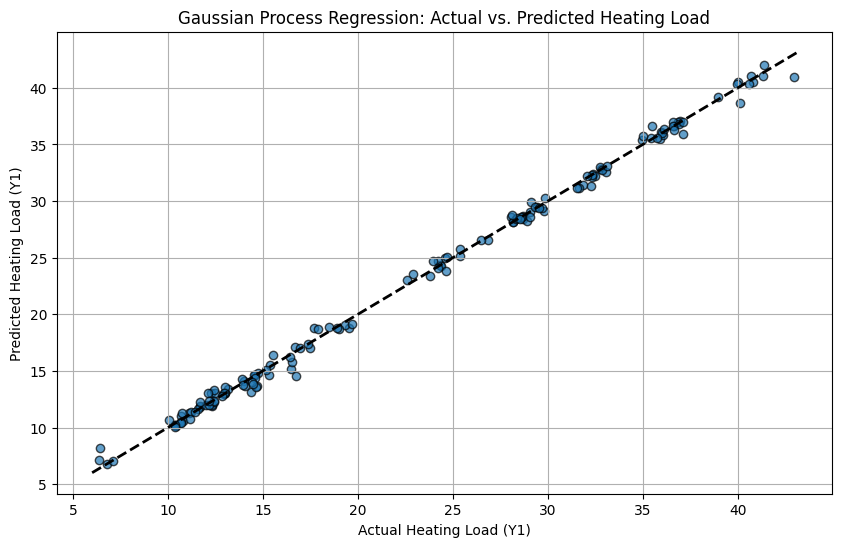

In [8]:
# Import necessary libraries
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Split data into training and testing sets
X_train_y1, X_test_y1, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)

# Define a kernel for the Gaussian Process.
# A common choice is the Radial Basis Function (RBF) kernel combined with a ConstantKernel.
kernel_y1 = C(1.0, (1e-3, 1e3)) * RBF(10.0, (1e-2, 1e2))

# Initialize the Gaussian Process Regressor
gp_y1 = GaussianProcessRegressor(kernel=kernel_y1, n_restarts_optimizer=10, random_state=42)

# Train the model
gp_y1.fit(X_train_y1, y1_train)

# Make predictions
y1_pred, y1_std = gp_y1.predict(X_test_y1, return_std=True)

# Evaluate the model
mse_y1 = mean_squared_error(y1_test, y1_pred)
r2_y1 = r2_score(y1_test, y1_pred)

print(f"Heating Load (Y1) - Mean Squared Error: {mse_y1:.4f}")
print(f"Heating Load (Y1) - R-squared: {r2_y1:.4f}")

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y1_test, y1_pred, edgecolors=(0, 0, 0), alpha=0.7)
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()], 'k--', lw=2)
plt.xlabel('Actual Heating Load (Y1)')
plt.ylabel('Predicted Heating Load (Y1)')
plt.title('Gaussian Process Regression: Actual vs. Predicted Heating Load')
plt.grid(True)
plt.show()

### Gaussian Process Regression for Cooling Load (Y2)

Cooling Load (Y2) - Mean Squared Error: 1.6234
Cooling Load (Y2) - R-squared: 0.9825


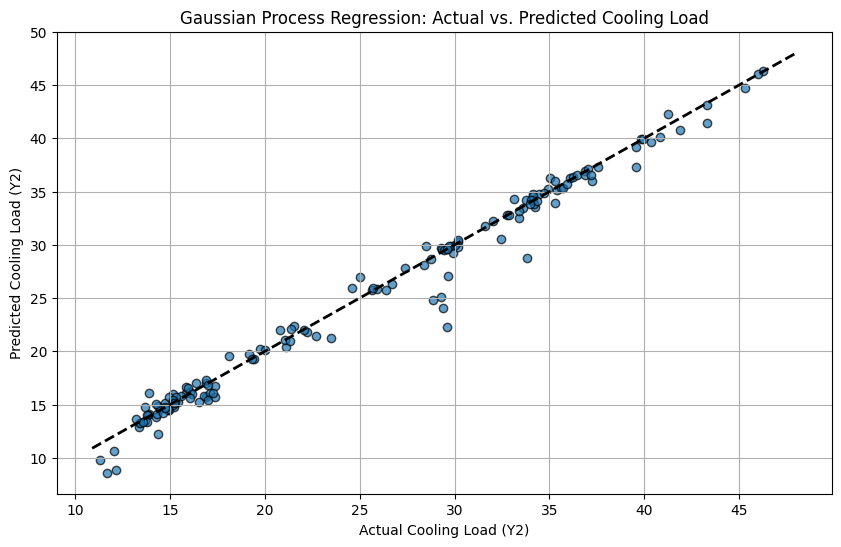

In [9]:
# Split data into training and testing sets for y2
X_train_y2, X_test_y2, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

# Define a kernel for the Gaussian Process for y2
kernel_y2 = C(1.0, (1e-3, 1e3)) * RBF(10.0, (1e-2, 1e2))

# Initialize the Gaussian Process Regressor for y2
gp_y2 = GaussianProcessRegressor(kernel=kernel_y2, n_restarts_optimizer=10, random_state=42)

# Train the model for y2
gp_y2.fit(X_train_y2, y2_train)

# Make predictions for y2
y2_pred, y2_std = gp_y2.predict(X_test_y2, return_std=True)

# Evaluate the model for y2
mse_y2 = mean_squared_error(y2_test, y2_pred)
r2_y2 = r2_score(y2_test, y2_pred)

print(f"Cooling Load (Y2) - Mean Squared Error: {mse_y2:.4f}")
print(f"Cooling Load (Y2) - R-squared: {r2_y2:.4f}")

# Plotting predictions vs actual values for y2
plt.figure(figsize=(10, 6))
plt.scatter(y2_test, y2_pred, edgecolors=(0, 0, 0), alpha=0.7)
plt.plot([y2.min(), y2.max()], [y2.min(), y2.max()], 'k--', lw=2)
plt.xlabel('Actual Cooling Load (Y2)')
plt.ylabel('Predicted Cooling Load (Y2)')
plt.title('Gaussian Process Regression: Actual vs. Predicted Cooling Load')
plt.grid(True)
plt.show()

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [10]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [16]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


In [17]:
display(df2.head())

,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


## Data Inspection and Preprocessing

In [18]:
print(df2.info())
print('\nMissing values per column:')
print(df2.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   indoor_temperature       2400 non-null   float64
 1   indoor_humidity          2400 non-null   float64
 2   co2_concentration        2400 non-null   float64
 3   indoor_lighting          2400 non-null   float64
 4   indoor_noise             2400 non-null   float64
 5   outdoor_temperature      2400 non-null   float64
 6   outdoor_humidity         2400 non-null   float64
 7   solar_radiation          2400 non-null   float64
 8   wind_speed               2400 non-null   float64
 9   rainfall                 2400 non-null   float64
 10  electricity_consumption  2400 non-null   float64
 11  heating_energy           2400 non-null   float64
 12  cooling_energy           2400 non-null   float64
 13  ventilation_rate         2400 non-null   float64
 14  equipment_load          

## Justification of Parameters for Linear Regression

To predict `predicted_energy_demand`, we will select features that are directly or indirectly responsible for a building's energy consumption. Based on the dataset description and general building physics principles, the following parameters are chosen:

*   **Energy Usage and Building Operation Features**: These are direct components or strong indicators of overall energy demand.
    *   `electricity_consumption`
    *   `heating_energy`
    *   `cooling_energy`
    *   `ventilation_rate`
    *   `equipment_load`

*   **Indoor Environmental Features**: These factors directly influence the need for HVAC (heating, ventilation, and air conditioning) systems, which are major energy consumers.
    *   `indoor_temperature`
    *   `indoor_humidity`
    *   `co2_concentration` (influences ventilation needs)
    *   `indoor_lighting` (contributes to electricity consumption)

*   **Outdoor Weather Features**: External conditions significantly impact the building's thermal loads and thus energy requirements.
    *   `outdoor_temperature`
    *   `outdoor_humidity`
    *   `solar_radiation`
    *   `wind_speed`
    *   `rainfall` (can affect building envelope and indirectly energy)

*   **Occupancy and Human Factors**: Human presence and activity contribute to internal heat gains and demand for environmental control.
    *   `occupancy`
    *   `activity_level`

We will exclude `indoor_noise` and `predicted_comfort_index` as they are more directly related to occupant comfort rather than directly driving energy demand in a straightforward linear fashion, especially when more direct energy-related features are available. The goal is to identify a strong linear relationship with direct energy drivers.

## Linear Regression Model for `predicted_energy_demand`

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define features (X) and target (y)
selected_features = [
    'indoor_temperature', 'indoor_humidity', 'co2_concentration', 'indoor_lighting',
    'outdoor_temperature', 'outdoor_humidity', 'solar_radiation', 'wind_speed', 'rainfall',
    'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate',
    'equipment_load', 'occupancy', 'activity_level'
]
X = df2[selected_features]
y = df2['predicted_energy_demand']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = linear_model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.4f}")
print(f"R-squared: {r2:.4f}")

Mean Squared Error: 3.6541
R-squared: 0.9609


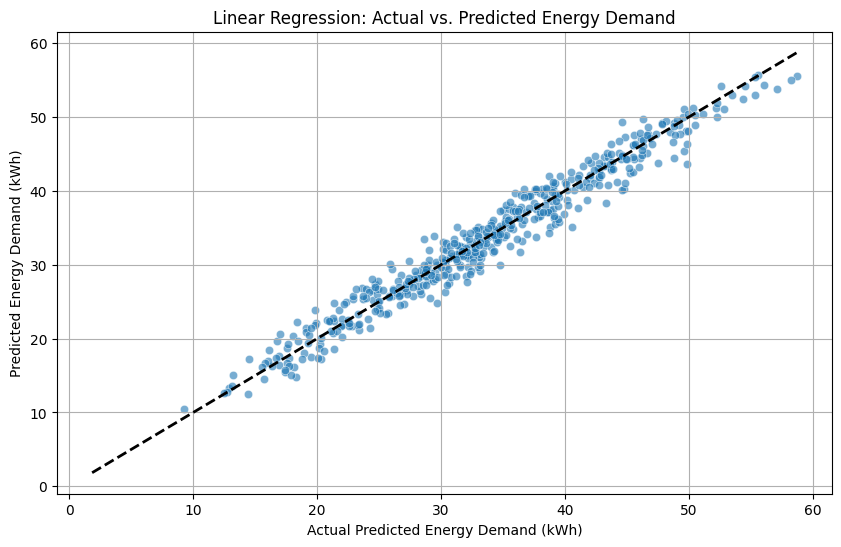

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting predictions vs actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Predicted Energy Demand (kWh)')
plt.ylabel('Predicted Energy Demand (kWh)')
plt.title('Linear Regression: Actual vs. Predicted Energy Demand')
plt.grid(True)
plt.show()